In [1]:
import numpy as np
import time
import pybullet as p
import pybullet_data
import scipy
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from get_robot_iiwa import sim_robot
import pickle
from matplotlib.patches import Ellipse
from gmr import GMM, plot_error_ellipses

pybullet build time: Oct 14 2023 15:43:53


In [2]:
path_folder = 'data/iiwa_dataset_mice'

joint_pos = np.load(path_folder+'/q_list.npy')

with open(path_folder + '/Joint_X_pos.pkl', 'rb') as f:
    Joint_X_pos = pickle.load(f)

with open(path_folder + '/Jacobians.pkl', 'rb') as f:
    Jacobians = pickle.load(f)

with open(path_folder + '/l.pkl', 'rb') as f:
    l = pickle.load(f)

with open(path_folder + '/v_max.pkl', 'rb') as f:
    v_max = pickle.load(f)

N = joint_pos.shape[0]
print(N)

2157817


In [3]:
X_5 = Joint_X_pos['5']
X_6 = Joint_X_pos['6']

X_5_split = np.hsplit(X_5[::200], 3)
X_6_split = np.hsplit(X_6[::200], 3)

l_5 = l['5']
l_6 = l['6']

v_5 = v_max['5']
v_6 = v_max['6']
print(np.array(X_6).shape)

(2157817, 3)


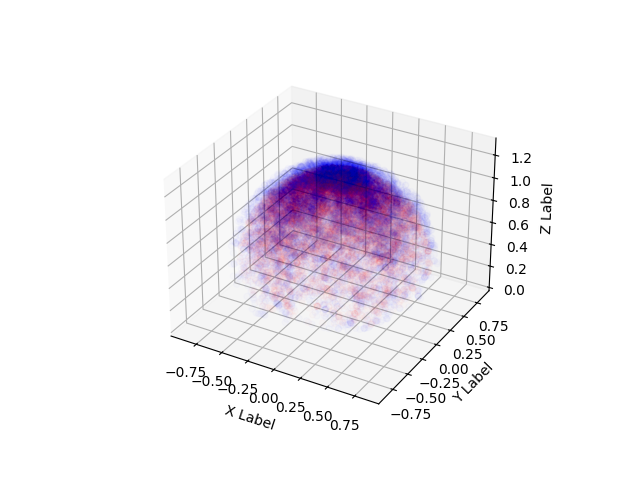

In [4]:
# %matplotlib notebook
%matplotlib widget
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_6_split[0], X_6_split[1], X_6_split[2], color='b', alpha = 0.01)
ax.scatter(X_5_split[0], X_5_split[1], X_5_split[2], color='r', alpha = 0.01)

ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

ax.tick_params(axis='both', which='major', labelsize=10)

plt.show()

## Plot a simple heat map

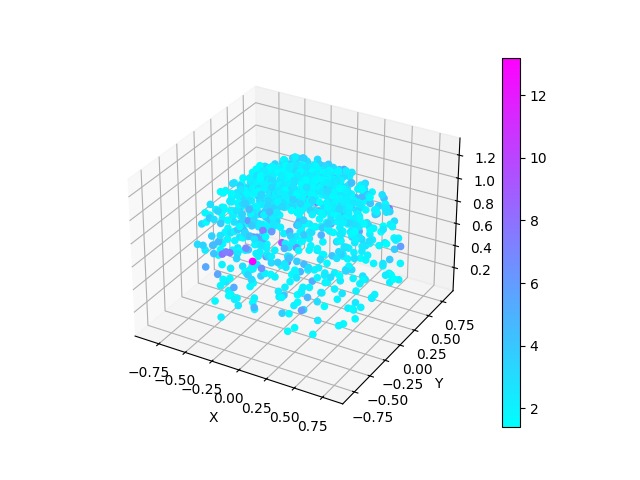

In [5]:
l6 = l_6[::2000]
X6 = X_6[::2000]
v6 = v_6[::2000]

idx = l6 <= 15

l_6_data = l6[idx]
X_6_data = X6[idx, :]

n_data = X_6_data.shape[0]

v_dir = np.array([0, 1, 0])
v_dir_tile = np.tile(v_dir, (n_data, 1))
v_dir_tile = v_dir_tile.astype(float)

v_dir_tile = np.multiply(v_dir_tile, l_6_data[:, np.newaxis])

%matplotlib widget

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
img = ax.scatter(X_6_data[:,0], X_6_data[:,1], X_6_data[:,2], c = l_6_data, cmap = 'cool', alpha = 1)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig.colorbar(img)

plt.show()

# GMM GMR

In [9]:
## Joint 6 (starting from the number 0)
l6 = l_6[::1000]
X6 = X_6[::1000]
v6 = v_6[::1000]

idx = l6 <= 10

l_6_data = l6[idx]
X_6_data = X6[idx, :]
v_6_data = v6[idx]

print(X_6_data.shape)
print(l_6_data.shape)
print(v_6_data.shape)

n_6_data = X_6_data.shape[0]


## Joint 5 (starting from the number 0)
l5 = l_5[::1000]
X5 = X_5[::1000]
v5 = v_5[::1000]

idx = l5 <= 20

l_5_data = l5[idx]
X_5_data = X5[idx, :]
v_5_data = v5[idx]

print(X_5_data.shape)
print(l_5_data.shape)
print(v_5_data.shape)

n_5_data = X_5_data.shape[0]

(2151, 3)
(2151,)
(2151,)
(2150, 3)
(2150,)
(2150,)


In [ ]:
gmm_full = GMM(n_components=8, )

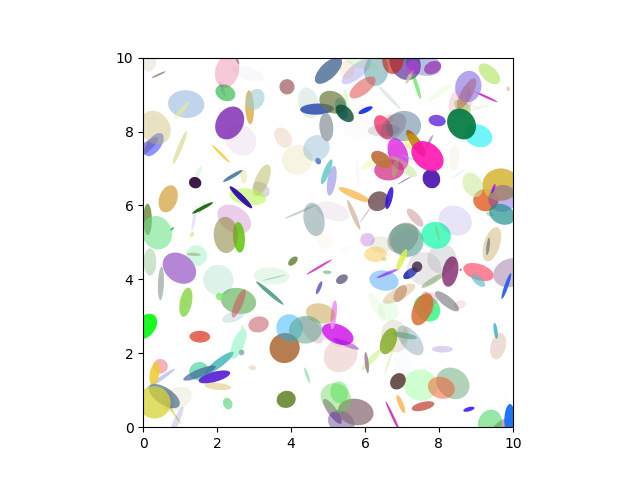

In [8]:
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.patches import Ellipse

# Fixing random state for reproducibility
np.random.seed(19680801)

NUM = 250

ells = [Ellipse(xy=np.random.rand(2) * 10,
                width=np.random.rand(), height=np.random.rand(),
                angle=np.random.rand() * 360)
        for i in range(NUM)]

fig, ax = plt.subplots()
ax.set(xlim=(0, 10), ylim=(0, 10), aspect="equal")

for e in ells:
    ax.add_artist(e)
    e.set_clip_box(ax.bbox)
    e.set_alpha(np.random.rand())
    e.set_facecolor(np.random.rand(3))

plt.show()